# Pareto/NBD

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import pymc as pm
import arviz as az
import pymc_marketing
from pymc_marketing.clv import ParetoNBDModel, BetaGeoModel
from pymc_marketing.clv.utils import rfm_summary

from pathlib import Path

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

from pymc_marketing.clv import ParetoNBDModel, rfm_summary
import inspect

from scipy.stats import pearsonr, spearmanr


In [4]:
df_calibration = pd.read_csv('calib_order_table.csv')

df_calibration['order_date'] = pd.to_datetime(df_calibration['order_date'])

In [5]:
df_calibration.info()

<class 'pandas.DataFrame'>
RangeIndex: 16501 entries, 0 to 16500
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Unnamed: 0       16501 non-null  int64         
 1   Customer_ID      16501 non-null  int64         
 2   order_date       16501 non-null  datetime64[us]
 3   total_amount     16501 non-null  float64       
 4   number_of_items  16501 non-null  int64         
 5   Country          16501 non-null  str           
 6   order_id         16501 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(3), str(2)
memory usage: 902.5 KB


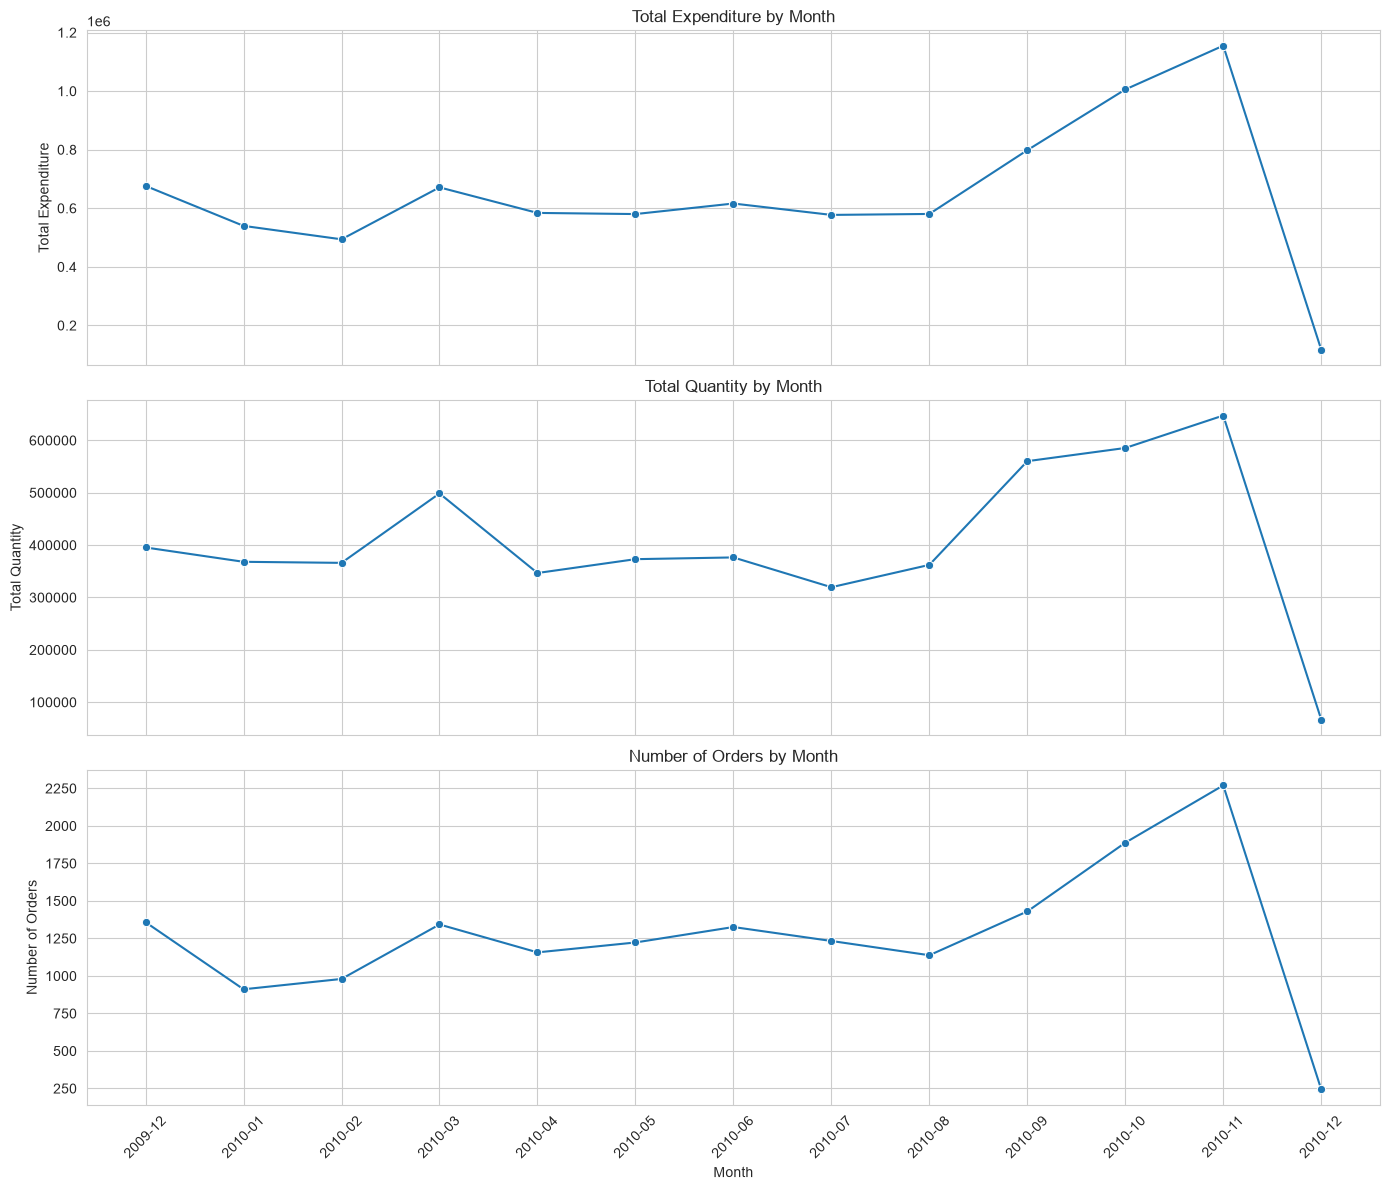

In [6]:
# make sure order_date is datetime

df_order_temp = df_calibration.copy()

# monthly aggregation
monthly = (
    df_order_temp
    .assign(month=df_order_temp["order_date"].dt.to_period("M").dt.to_timestamp())
    .groupby("month", as_index=False)
    .agg(
        total_expenditure=("total_amount", "sum"),
        total_quantity=("number_of_items", "sum"),
        number_of_orders=("order_id", "nunique")
    )
    .sort_values("month")
)

monthly["month_label"] = monthly["month"].dt.strftime("%Y-%m")

sns.set_style("whitegrid")

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

sns.lineplot(data=monthly, x="month_label", y="total_expenditure", marker="o", ax=axes[0])
axes[0].set_title("Total Expenditure by Month")
axes[0].set_xlabel("")
axes[0].set_ylabel("Total Expenditure")

sns.lineplot(data=monthly, x="month_label", y="total_quantity", marker="o", ax=axes[1])
axes[1].set_title("Total Quantity by Month")
axes[1].set_xlabel("")
axes[1].set_ylabel("Total Quantity")

sns.lineplot(data=monthly, x="month_label", y="number_of_orders", marker="o", ax=axes[2])
axes[2].set_title("Number of Orders by Month")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Number of Orders")

for ax in axes:
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [7]:
# sort chronologically
df_calibration = df_calibration.sort_values(
    ["order_date", "Customer_ID", "order_id"]
).reset_index(drop=True)

n = len(df_calibration)

start_time = df_calibration["order_date"].min()
end_time = df_calibration["order_date"].max()

## time-warping / de-seasonalization step.
span_seconds = (end_time - start_time).total_seconds()

# rank-based scaled time in [0, 1]
if n == 1:
    df_calibration["scaled_u"] = 0.0
else:
    df_calibration["scaled_u"] = np.arange(n) / (n - 1)

# map to actual calendar span
df_calibration["scaled_time"] = start_time + pd.to_timedelta(
    df_calibration["scaled_u"] * span_seconds,
    unit="s"
)

df_calibration["scaled_time2"] = (
    df_calibration["order_date"]
    + (df_calibration["scaled_time"] - df_calibration["order_date"]) / 2
)

df_calibration.drop(columns=['scaled_u', 'order_date'], inplace=True)
df_calibration.info()

<class 'pandas.DataFrame'>
RangeIndex: 16501 entries, 0 to 16500
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Unnamed: 0       16501 non-null  int64         
 1   Customer_ID      16501 non-null  int64         
 2   total_amount     16501 non-null  float64       
 3   number_of_items  16501 non-null  int64         
 4   Country          16501 non-null  str           
 5   order_id         16501 non-null  str           
 6   scaled_time      16501 non-null  datetime64[ns]
 7   scaled_time2     16501 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(3), str(2)
memory usage: 1.0 MB


## Fitting Pareto/NBD Using pymc marketing

In [9]:
summary_cal = rfm_summary(
    transactions=df_calibration,
    customer_id_col="Customer_ID",
    datetime_col="scaled_time",
    monetary_value_col="total_amount",
    observation_period_end=df_calibration["scaled_time"].max(),
    time_unit="D"
)

pareto_model = ParetoNBDModel(data=summary_cal)
pareto_model.fit(method="map")

out = Path("pareto_nbd_fit.nc")
if out.exists():
    out.unlink()

pareto_model.save(out)

Output()

In [20]:
holdout_period = 369

summary_cal["predicted_transactions"] = (
    pareto_model.expected_purchases(
        data=summary_cal,
        future_t=holdout_period
    )
    .mean(("chain", "draw"))
    .values
)

summary_cal.to_csv('lifetimes.csv')

In [21]:
df_holdout = pd.read_csv('holdout_order_table.csv')

df_holdout['order_date'] = pd.to_datetime(df_holdout['order_date'])

df_holdout.info()

<class 'pandas.DataFrame'>
RangeIndex: 16443 entries, 0 to 16442
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Unnamed: 0       16443 non-null  int64         
 1   Customer_ID      16443 non-null  int64         
 2   order_date       16443 non-null  datetime64[us]
 3   total_amount     16443 non-null  float64       
 4   number_of_items  16443 non-null  int64         
 5   Country          16443 non-null  str           
 6   order_id         16443 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(3), str(2)
memory usage: 899.4 KB


In [22]:
# Use the trained Pareto model to simulate and predict future purchase counts for each customer
pred_orders = pareto_model.expected_purchases(data=summary_cal, future_t=holdout_period)

# 1. Isolate the customer IDs into a fresh DataFrame copy
# 2. Average the complex Bayesian simulation chains and draws down to a single prediction number
# 3. Add those finalized average values as a new column named 'predicted_orders_holdout'
pareto_pred = summary_cal[["customer_id"]].copy().assign(
    predicted_orders_holdout=pred_orders.mean(("chain", "draw")).values
)

# Export the final customer IDs and their predicted purchase counts to a clean CSV file without the index row
pareto_pred.to_csv("pareto_predicted_orders_holdout.csv", index=False)

## Churn and zero purchase in the holdout period

In [23]:
# probability customer is alive after calibration
p_alive = pareto_model.expected_probability_alive(data=summary_cal)

evaluation = summary_cal.copy()
evaluation["p_alive"] = np.asarray(p_alive).ravel()

# actual churn = no purchase in holdout
holdout_customers = set(df_holdout["Customer_ID"].unique())
evaluation["actual_churned"] = (~evaluation["customer_id"].isin(holdout_customers)).astype(int)

# predicted churn = 1 - p_alive
evaluation["pred_churn_prob"] = 1 - evaluation["p_alive"]
evaluation["pred_churned"] = (evaluation["pred_churn_prob"] >= 0.5).astype(int)

y_true = evaluation["actual_churned"]
y_pred = evaluation["pred_churned"]
y_score = evaluation["pred_churn_prob"]

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

print("ROC AUC:")
print(roc_auc_score(y_true, y_score))

Confusion Matrix:
[[2698    3]
 [1569    8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.63      1.00      0.77      2701
           1       0.73      0.01      0.01      1577

    accuracy                           0.63      4278
   macro avg       0.68      0.50      0.39      4278
weighted avg       0.67      0.63      0.49      4278

ROC AUC:
0.7486639791692735


In [24]:
evaluation["p0"] = np.asarray(
    pareto_model.expected_purchase_probability(
        data=summary_cal,
        n_purchases=0,
        future_t=holdout_period
    )
).ravel()

actual = df_holdout.groupby("Customer_ID")["order_id"].nunique()
evaluation["actual_purchases"] = evaluation["customer_id"].map(actual).fillna(0)

expected_no_purchase = evaluation["p0"].sum()



# Probability alive for each customer
p_alive = pareto_model.expected_probability_alive(data=summary_cal)

evaluation["p_alive"] = np.asarray(p_alive).ravel()

# Expected numbers
expected_alive = evaluation["p_alive"].sum()
expected_churned = len(evaluation) - expected_alive

# Actual number of churned customers
holdout_customers = set(df_holdout["Customer_ID"].unique())
actual_churned = (
    ~evaluation["customer_id"].isin(holdout_customers)
).sum()


expected_no_purchase = evaluation["p0"].sum()
actual_no_purchase = (evaluation["actual_purchases"] == 0).sum()

print(f"Number of customers        : {len(evaluation)}")
print(f"Expected alive customers   : {expected_alive:.2f}")
print(f"Expected churned customers : {expected_churned:.2f}")
print(f"Actual churned customers   : {actual_churned}")

print(f"Expected customers with no purchase : {expected_no_purchase:.2f}")
print(f"Actual customers with no purchase   : {actual_no_purchase}")

Number of customers        : 4278
Expected alive customers   : 4167.19
Expected churned customers : 110.81
Actual churned customers   : 1577
Expected customers with no purchase : 1060.28
Actual customers with no purchase   : 1577


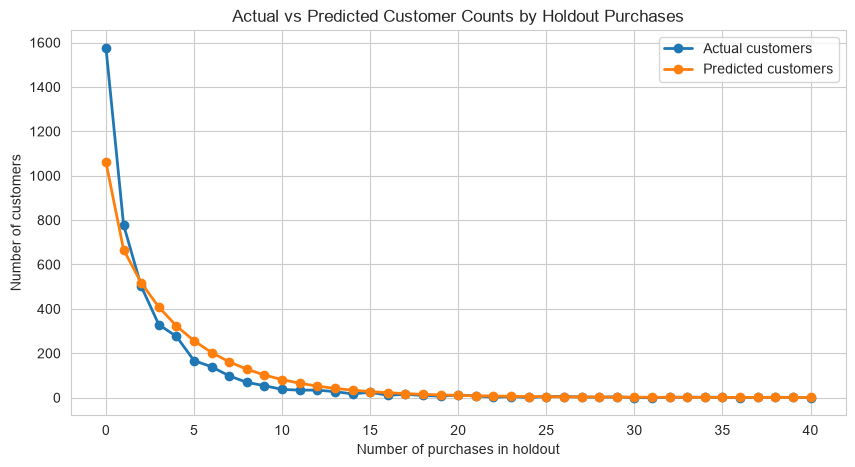

In [25]:
# actual purchases per customer in holdout
actual = df_holdout.groupby("Customer_ID")["order_id"].nunique()
evaluation["actual_purchases"] = evaluation["customer_id"].map(actual).fillna(0).astype(int)

# predicted and actual customer counts for 0..40 purchases in holdout
max_n = 40
n_vals = list(range(max_n + 1))

pred_counts = []
for n in n_vals:
    p_n = np.asarray(
        pareto_model.expected_purchase_probability(
            data=summary_cal,
            n_purchases=n,
            future_t=holdout_period
        )
    ).ravel()
    pred_counts.append(p_n.sum())

actual_counts = (
    evaluation["actual_purchases"]
    .value_counts()
    .reindex(n_vals, fill_value=0)
    .sort_index()
)

count_summary = pd.DataFrame({
    "n_purchases": n_vals,
    "predicted_customers": pred_counts,
    "actual_customers": actual_counts.values
})



plt.figure(figsize=(10, 5))
plt.plot(count_summary["n_purchases"], count_summary["actual_customers"], marker="o", linewidth=2, label="Actual customers")
plt.plot(count_summary["n_purchases"], count_summary["predicted_customers"], marker="o", linewidth=2, label="Predicted customers")
plt.xlabel("Number of purchases in holdout")
plt.ylabel("Number of customers")
plt.title("Actual vs Predicted Customer Counts by Holdout Purchases")
plt.grid(True)
plt.legend()
plt.show()

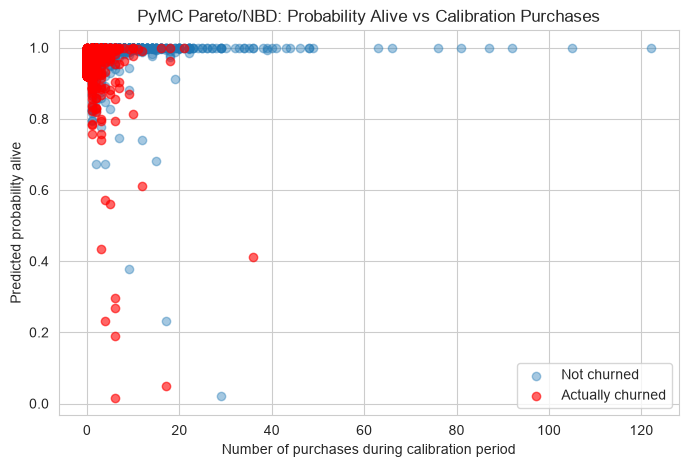

In [26]:
holdout_customers = set(df_holdout["Customer_ID"].unique())

evaluation["actual_churned"] = (
    ~evaluation["customer_id"].isin(holdout_customers)
).astype(int)

plot_data = evaluation.dropna(subset=["p_alive"]).copy()

not_churned = plot_data[plot_data["actual_churned"] == 0]
churned = plot_data[plot_data["actual_churned"] == 1]

plt.figure(figsize=(8, 5))

plt.scatter(
    not_churned["frequency"],
    not_churned["p_alive"],
    alpha=0.4,
    label="Not churned"
)

plt.scatter(
    churned["frequency"],
    churned["p_alive"],
    color="red",
    alpha=0.6,
    label="Actually churned"
)

plt.xlabel("Number of purchases during calibration period")
plt.ylabel("Predicted probability alive")
plt.title("PyMC Pareto/NBD: Probability Alive vs Calibration Purchases")
plt.grid(True)
plt.legend()
plt.show()

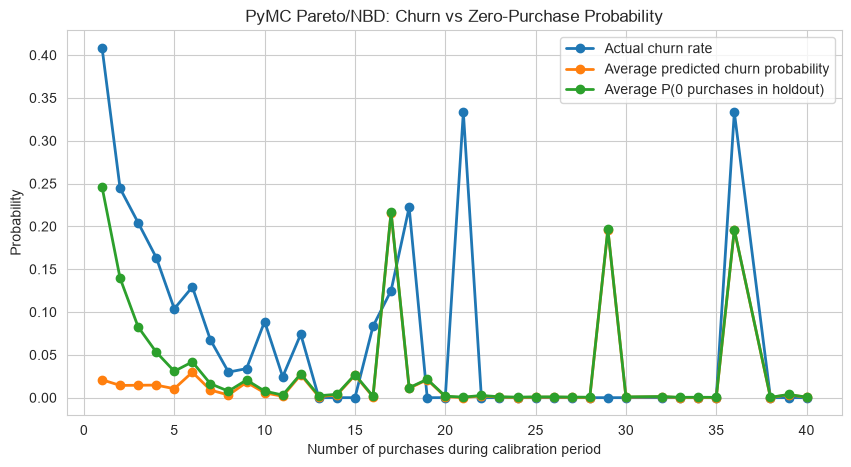

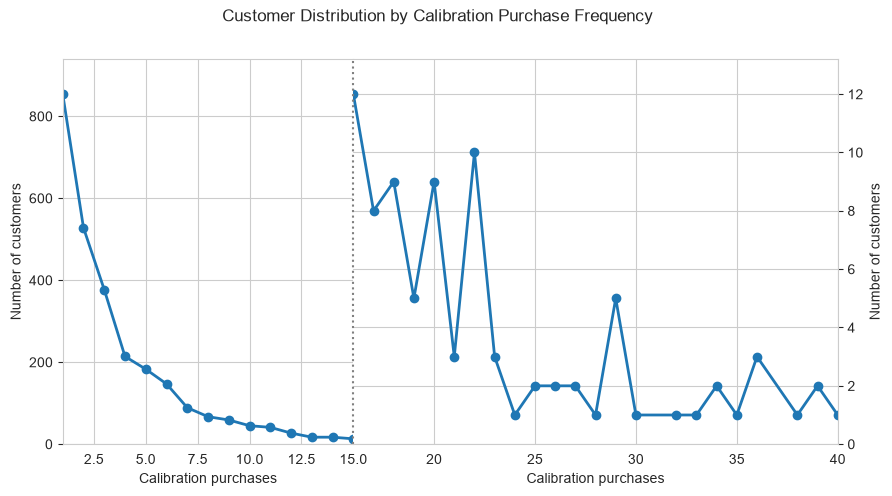

In [27]:
holdout_customers = set(df_holdout["Customer_ID"].unique())

evaluation["actual_churned"] = (
    ~evaluation["customer_id"].isin(holdout_customers)
).astype(int)

evaluation["p_alive"] = np.asarray(
    pareto_model.expected_probability_alive(data=summary_cal)
).ravel()

evaluation["p0"] = np.asarray(
    pareto_model.expected_purchase_probability(
        data=summary_cal,
        n_purchases=0,
        future_t=holdout_period
    )
).ravel()

plot_data = evaluation.dropna(subset=["p_alive", "p0", "actual_churned"]).copy()
plot_data["pred_churn_prob"] = 1 - plot_data["p_alive"]

freq_summary = (
    plot_data[
        (plot_data["frequency"] >= 1) &
        (plot_data["frequency"] <= 40)
    ]
    .groupby("frequency")
    .agg(
        actual_churn_rate=("actual_churned", "mean"),
        avg_pred_churn_prob=("pred_churn_prob", "mean"),
        avg_p0=("p0", "mean"),
        n_customers=("actual_churned", "size")
    )
    .reset_index()
)

plt.figure(figsize=(10, 5))
plt.plot(freq_summary["frequency"], freq_summary["actual_churn_rate"], marker="o", linewidth=2, label="Actual churn rate")
plt.plot(freq_summary["frequency"], freq_summary["avg_pred_churn_prob"], marker="o", linewidth=2, label="Average predicted churn probability")
plt.plot(freq_summary["frequency"], freq_summary["avg_p0"], marker="o", linewidth=2, label="Average P(0 purchases in holdout)")
plt.xlabel("Number of purchases during calibration period")
plt.ylabel("Probability")
plt.title("PyMC Pareto/NBD: Churn vs Zero-Purchase Probability")
plt.grid(True)
plt.legend()
plt.show()


#===================================================================

split_freq = 15

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(10, 5),
    gridspec_kw={"width_ratios": [15, 25]},
    sharex=False,
    sharey=False
)

left = freq_summary[freq_summary["frequency"] <= split_freq]
right = freq_summary[freq_summary["frequency"] > split_freq]

ax1.plot(left["frequency"], left["n_customers"], marker="o", linewidth=2)
ax2.plot(right["frequency"], right["n_customers"], marker="o", linewidth=2)

# x limits
ax1.set_xlim(1, 15)
ax2.set_xlim(16, 40)

# independent y limits
ax1.set_ylim(0, left["n_customers"].max() * 1.1)
ax2.set_ylim(0, right["n_customers"].max() * 1.1)

# remove touching spines
ax1.spines["right"].set_visible(False)
ax2.spines["left"].set_visible(False)

# left y-axis
ax1.yaxis.set_ticks_position("left")
ax1.yaxis.set_label_position("left")
ax1.set_ylabel("Number of customers")

# right y-axis
ax2.yaxis.set_ticks_position("right")
ax2.yaxis.set_label_position("right")
ax2.set_ylabel("Number of customers")

# x labels
ax1.set_xlabel("Calibration purchases")
ax2.set_xlabel("Calibration purchases")

# dotted separator
ax1.axvline(
    x=15,
    color="gray",
    linestyle=":",
    linewidth=1.5
)

ax2.axvline(
    x=16,
    color="gray",
    linestyle=":",
    linewidth=1.5
)

fig.suptitle("Customer Distribution by Calibration Purchase Frequency")

# panels touch each other
plt.subplots_adjust(wspace=0)

plt.show()

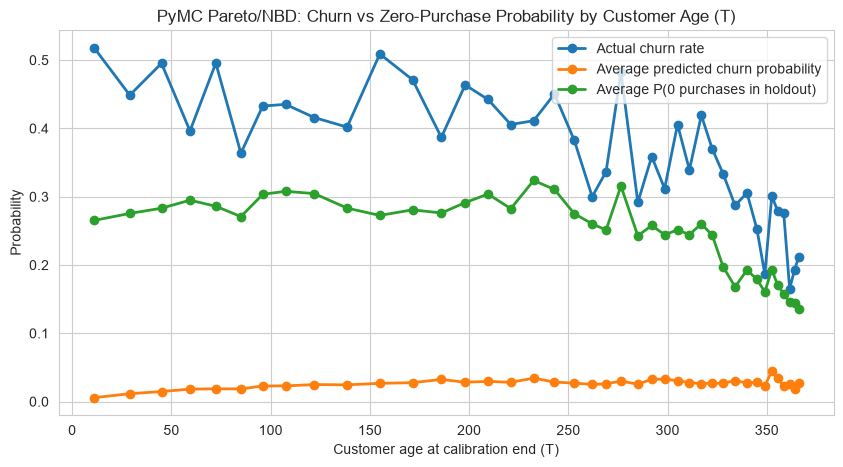

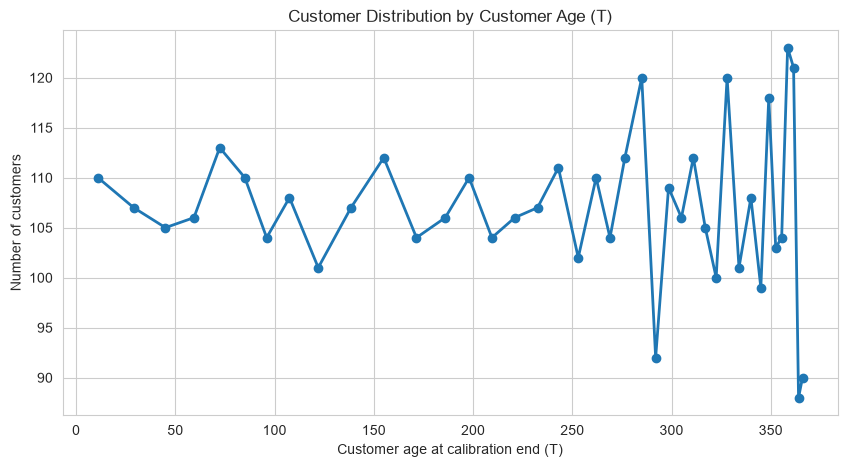

In [28]:
holdout_customers = set(df_holdout["Customer_ID"].unique())

evaluation["actual_churned"] = (
    ~evaluation["customer_id"].isin(holdout_customers)
).astype(int)

evaluation["p_alive"] = np.asarray(
    pareto_model.expected_probability_alive(data=summary_cal)
).ravel()

evaluation["p0"] = np.asarray(
    pareto_model.expected_purchase_probability(
        data=summary_cal,
        n_purchases=0,
        future_t=holdout_period
    )
).ravel()

plot_data = evaluation.dropna(subset=["p_alive", "p0", "actual_churned", "T"]).copy()
plot_data["pred_churn_prob"] = 1 - plot_data["p_alive"]

# 40 classes for T
plot_data["T_class"] = pd.qcut(
    plot_data["T"],
    q=40,
    duplicates="drop"
)

T_summary = (
    plot_data
    .groupby("T_class", observed=True)
    .agg(
        actual_churn_rate=("actual_churned", "mean"),
        avg_pred_churn_prob=("pred_churn_prob", "mean"),
        avg_p0=("p0", "mean"),
        n_customers=("actual_churned", "size")
    )
    .reset_index()
)

T_summary["T_mid"] = T_summary["T_class"].apply(lambda x: (x.left + x.right) / 2)
T_summary = T_summary.sort_values("T_mid").reset_index(drop=True)

# --------------------------------------------------
# Figure 1: churn-related curves vs T
# --------------------------------------------------
plt.figure(figsize=(10, 5))

plt.plot(
    T_summary["T_mid"],
    T_summary["actual_churn_rate"],
    marker="o",
    linewidth=2,
    label="Actual churn rate"
)

plt.plot(
    T_summary["T_mid"],
    T_summary["avg_pred_churn_prob"],
    marker="o",
    linewidth=2,
    label="Average predicted churn probability"
)

plt.plot(
    T_summary["T_mid"],
    T_summary["avg_p0"],
    marker="o",
    linewidth=2,
    label="Average P(0 purchases in holdout)"
)

plt.xlabel("Customer age at calibration end (T)")
plt.ylabel("Probability")
plt.title("PyMC Pareto/NBD: Churn vs Zero-Purchase Probability by Customer Age (T)")
plt.grid(True)
plt.legend()
plt.show()

# --------------------------------------------------
# Figure 2: customer distribution by T class
# --------------------------------------------------
plt.figure(figsize=(10, 5))

plt.plot(
    T_summary["T_mid"],
    T_summary["n_customers"],
    marker="o",
    linewidth=2
)

plt.xlabel("Customer age at calibration end (T)")
plt.ylabel("Number of customers")
plt.title("Customer Distribution by Customer Age (T)")
plt.grid(True)
plt.show()

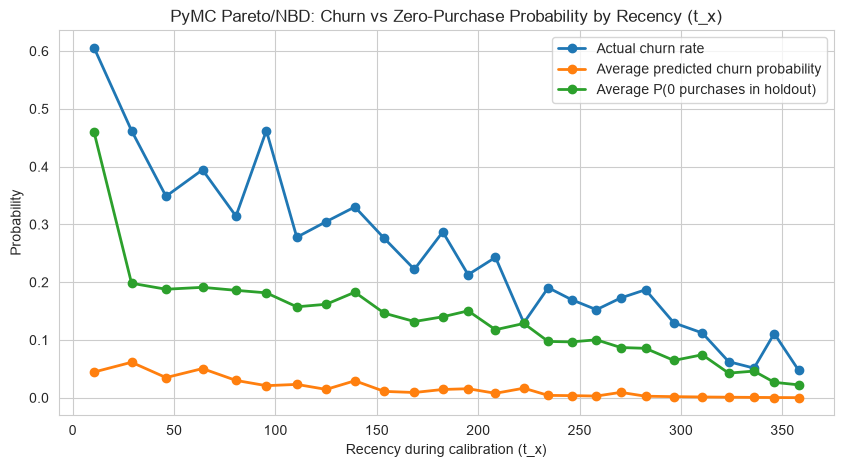

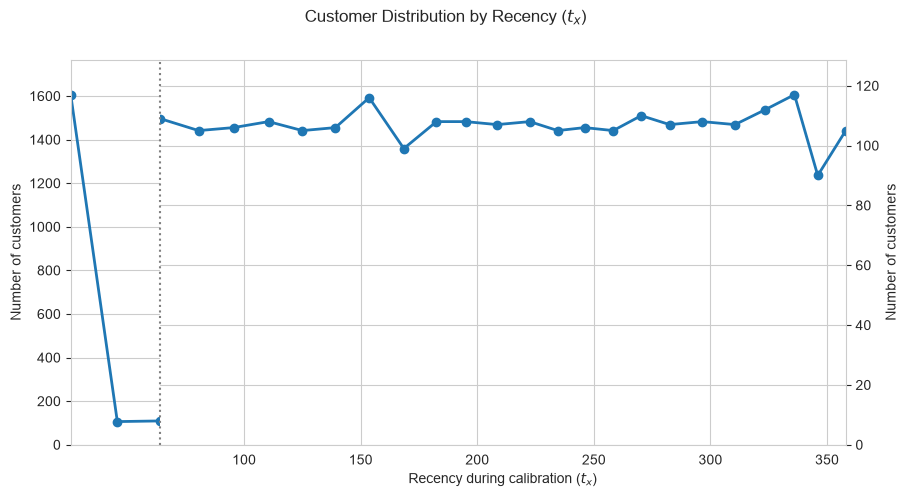

In [29]:
holdout_customers = set(df_holdout["Customer_ID"].unique())

evaluation["actual_churned"] = (
    ~evaluation["customer_id"].isin(holdout_customers)
).astype(int)

evaluation["p_alive"] = np.asarray(
    pareto_model.expected_probability_alive(data=summary_cal)
).ravel()

evaluation["p0"] = np.asarray(
    pareto_model.expected_purchase_probability(
        data=summary_cal,
        n_purchases=0,
        future_t=holdout_period
    )
).ravel()

plot_data = evaluation.dropna(subset=["p_alive", "p0", "actual_churned", "recency"]).copy()
plot_data["pred_churn_prob"] = 1 - plot_data["p_alive"]

# 40 classes for t_x (recency)
plot_data["tx_class"] = pd.qcut(
    plot_data["recency"],
    q=40,
    duplicates="drop"
)

tx_summary = (
    plot_data
    .groupby("tx_class", observed=True)
    .agg(
        actual_churn_rate=("actual_churned", "mean"),
        avg_pred_churn_prob=("pred_churn_prob", "mean"),
        avg_p0=("p0", "mean"),
        n_customers=("actual_churned", "size")
    )
    .reset_index()
)

tx_summary["tx_mid"] = tx_summary["tx_class"].apply(lambda x: (x.left + x.right) / 2)
tx_summary = tx_summary.sort_values("tx_mid").reset_index(drop=True)

# --------------------------------------------------
# Figure 1: churn-related curves vs t_x
# --------------------------------------------------
plt.figure(figsize=(10, 5))

plt.plot(
    tx_summary["tx_mid"],
    tx_summary["actual_churn_rate"],
    marker="o",
    linewidth=2,
    label="Actual churn rate"
)

plt.plot(
    tx_summary["tx_mid"],
    tx_summary["avg_pred_churn_prob"],
    marker="o",
    linewidth=2,
    label="Average predicted churn probability"
)

plt.plot(
    tx_summary["tx_mid"],
    tx_summary["avg_p0"],
    marker="o",
    linewidth=2,
    label="Average P(0 purchases in holdout)"
)

plt.xlabel("Recency during calibration (t_x)")
plt.ylabel("Probability")
plt.title("PyMC Pareto/NBD: Churn vs Zero-Purchase Probability by Recency (t_x)")
plt.grid(True)
plt.legend()
plt.show()

# --------------------------------------------------
# Figure 2: customer distribution by t_x
# --------------------------------------------------


fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(10, 5),
    gridspec_kw={"width_ratios": [3, max(len(tx_summary)-3, 1)]},
    sharex=False,
    sharey=False
)

left = tx_summary.iloc[:3]
right = tx_summary.iloc[3:]

ax1.plot(left["tx_mid"], left["n_customers"], marker="o", linewidth=2)
ax2.plot(right["tx_mid"], right["n_customers"], marker="o", linewidth=2)

# x limits
ax1.set_xlim(left["tx_mid"].min(), left["tx_mid"].max())
ax2.set_xlim(right["tx_mid"].min(), right["tx_mid"].max())

# independent y limits
ax1.set_ylim(0, left["n_customers"].max() * 1.1)
ax2.set_ylim(0, right["n_customers"].max() * 1.1)

# remove touching spines
ax1.spines["right"].set_visible(False)
ax2.spines["left"].set_visible(False)

# y axes
ax1.yaxis.set_ticks_position("left")
ax1.yaxis.set_label_position("left")
ax1.set_ylabel("Number of customers")

ax2.yaxis.set_ticks_position("right")
ax2.yaxis.set_label_position("right")
ax2.set_ylabel("Number of customers")

# x labels

ax2.set_xlabel("Recency during calibration ($t_x$)")

# dotted separator
ax1.axvline(
    left["tx_mid"].max(),
    color="gray",
    linestyle=":",
    linewidth=1.5
)

ax2.axvline(
    right["tx_mid"].min(),
    color="gray",
    linestyle=":",
    linewidth=1.5
)

# -------------------------------
# Custom ticks every 50 units
# -------------------------------
xmin = int(np.floor(tx_summary["tx_mid"].min() / 50) * 50)
xmax = int(np.ceil(tx_summary["tx_mid"].max() / 50) * 50)

ticks = np.arange(xmin, xmax + 1, 50)

ax1.set_xticks([t for t in ticks if left["tx_mid"].min() <= t <= left["tx_mid"].max()])
ax2.set_xticks([t for t in ticks if right["tx_mid"].min() <= t <= right["tx_mid"].max()])

ax1.grid(True)
ax2.grid(True)

fig.suptitle("Customer Distribution by Recency ($t_x$)")

plt.subplots_adjust(wspace=0)
plt.show()

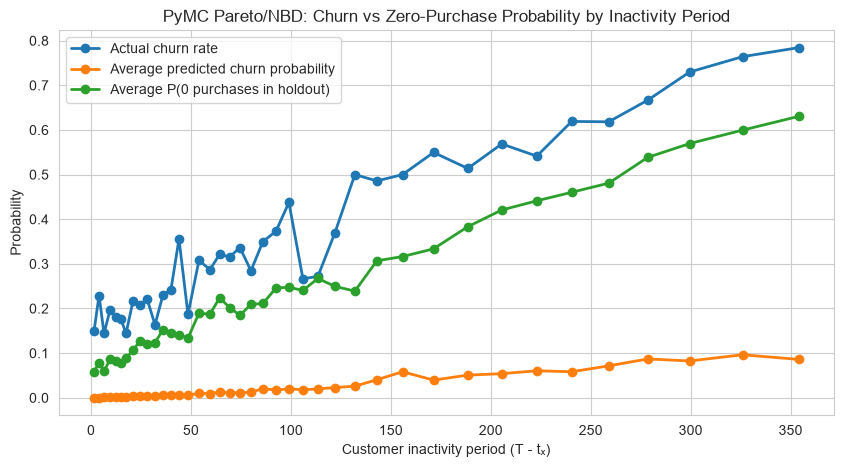

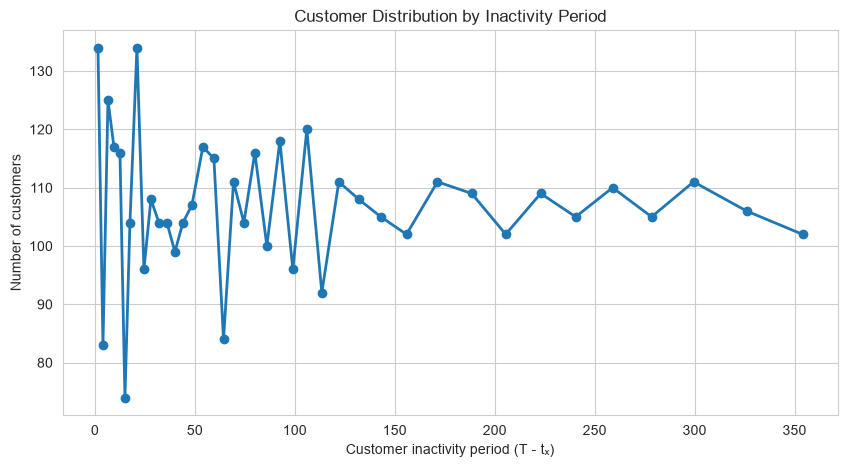

In [30]:
holdout_customers = set(df_holdout["Customer_ID"].unique())

evaluation["actual_churned"] = (
    ~evaluation["customer_id"].isin(holdout_customers)
).astype(int)

evaluation["p_alive"] = np.asarray(
    pareto_model.expected_probability_alive(data=summary_cal)
).ravel()

evaluation["p0"] = np.asarray(
    pareto_model.expected_purchase_probability(
        data=summary_cal,
        n_purchases=0,
        future_t=holdout_period
    )
).ravel()

plot_data = evaluation.dropna(subset=["p_alive", "p0", "actual_churned", "T", "recency"]).copy()
plot_data["pred_churn_prob"] = 1 - plot_data["p_alive"]
plot_data["inactivity"] = plot_data["T"] - plot_data["recency"]

# 40 classes for inactivity period
plot_data["inact_class"] = pd.qcut(
    plot_data["inactivity"],
    q=40,
    duplicates="drop"
)

inact_summary = (
    plot_data
    .groupby("inact_class", observed=True)
    .agg(
        actual_churn_rate=("actual_churned", "mean"),
        avg_pred_churn_prob=("pred_churn_prob", "mean"),
        avg_p0=("p0", "mean"),
        n_customers=("actual_churned", "size")
    )
    .reset_index()
)

inact_summary["inact_mid"] = inact_summary["inact_class"].apply(
    lambda x: (x.left + x.right) / 2
)
inact_summary = inact_summary.sort_values("inact_mid").reset_index(drop=True)

# --------------------------------------------------
# Figure 1: churn-related curves vs inactivity period
# --------------------------------------------------
plt.figure(figsize=(10, 5))

plt.plot(
    inact_summary["inact_mid"],
    inact_summary["actual_churn_rate"],
    marker="o",
    linewidth=2,
    label="Actual churn rate"
)

plt.plot(
    inact_summary["inact_mid"],
    inact_summary["avg_pred_churn_prob"],
    marker="o",
    linewidth=2,
    label="Average predicted churn probability"
)

plt.plot(
    inact_summary["inact_mid"],
    inact_summary["avg_p0"],
    marker="o",
    linewidth=2,
    label="Average P(0 purchases in holdout)"
)

plt.xlabel("Customer inactivity period (T - tₓ)")
plt.ylabel("Probability")
plt.title("PyMC Pareto/NBD: Churn vs Zero-Purchase Probability by Inactivity Period")
plt.grid(True)
plt.legend()
plt.show()

# --------------------------------------------------
# Figure 2: customer distribution by inactivity period
# --------------------------------------------------
plt.figure(figsize=(10, 5))

plt.plot(
    inact_summary["inact_mid"],
    inact_summary["n_customers"],
    marker="o",
    linewidth=2
)

plt.xlabel("Customer inactivity period (T - tₓ)")
plt.ylabel("Number of customers")
plt.title("Customer Distribution by Inactivity Period")
plt.grid(True)
plt.show()

## Number of Purchases in the Holdout Period: Predicted vs Actual

In [31]:
# Predict expected purchases during the holdout period
pred = pareto_model.expected_purchases(
    data=summary_cal,
    future_t=holdout_period
)

In [32]:
evaluation = summary_cal.copy()
evaluation["pred_purchases"] = np.asarray(pred).ravel()

# Actual purchases in the holdout period
actual = (
    df_holdout
    .groupby("Customer_ID")["order_id"]
    .nunique()
)

evaluation["actual_purchases"] = (
    evaluation["customer_id"]
    .map(actual)
    .fillna(0)
)

print("Total actual purchases   :", evaluation["actual_purchases"].sum())
print("Total predicted purchases:", evaluation["pred_purchases"].sum())

print("MAE :", mean_absolute_error(
    evaluation["actual_purchases"],
    evaluation["pred_purchases"]
))

print("RMSE:", np.sqrt(mean_squared_error(
    evaluation["actual_purchases"],
    evaluation["pred_purchases"]
)))

Total actual purchases   : 12572.0
Total predicted purchases: 17142.643098801447
MAE : 2.2832545813489555
RMSE: 3.436523536060471


In [33]:
print("Pearson :", pearsonr(
    evaluation["actual_purchases"],
    evaluation["pred_purchases"]
)[0])

print("Spearman:", spearmanr(
    evaluation["actual_purchases"],
    evaluation["pred_purchases"]
)[0])

Pearson : 0.8393055507257416
Spearman: 0.5931663565056803


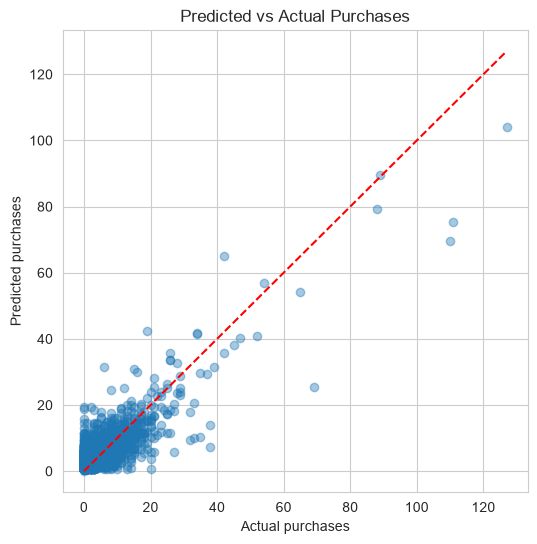

In [34]:
plt.figure(figsize=(6,6))

plt.scatter(
    evaluation["actual_purchases"],
    evaluation["pred_purchases"],
    alpha=0.4
)

m = max(
    evaluation["actual_purchases"].max(),
    evaluation["pred_purchases"].max()
)

plt.plot([0,m],[0,m],'r--')

plt.xlabel("Actual purchases")
plt.ylabel("Predicted purchases")
plt.title("Predicted vs Actual Purchases")

plt.show()

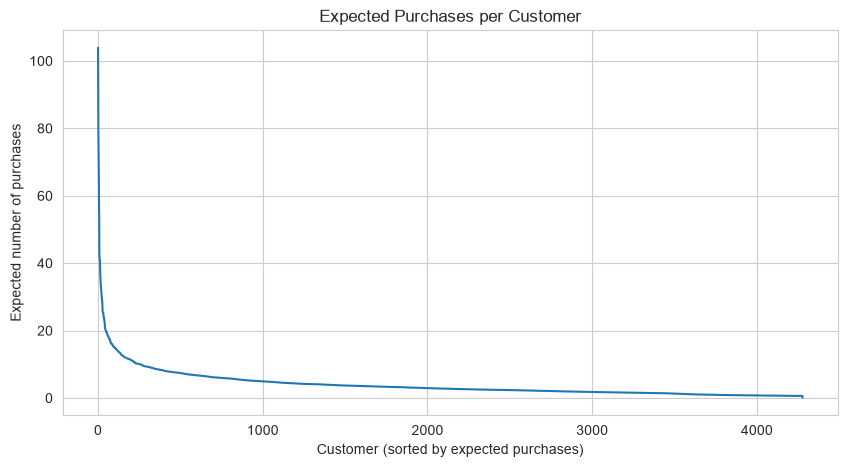

In [35]:
plot_data = (
    evaluation["pred_purchases"]
    .sort_values(ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 5))

plt.plot(
    plot_data,
    linewidth=1.5
)

plt.xlabel("Customer (sorted by expected purchases)")
plt.ylabel("Expected number of purchases")
plt.title("Expected Purchases per Customer")
plt.grid(True)

plt.show()

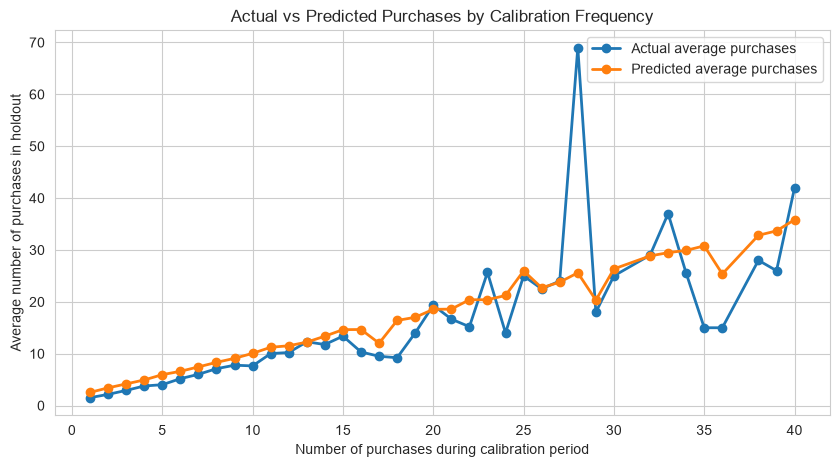

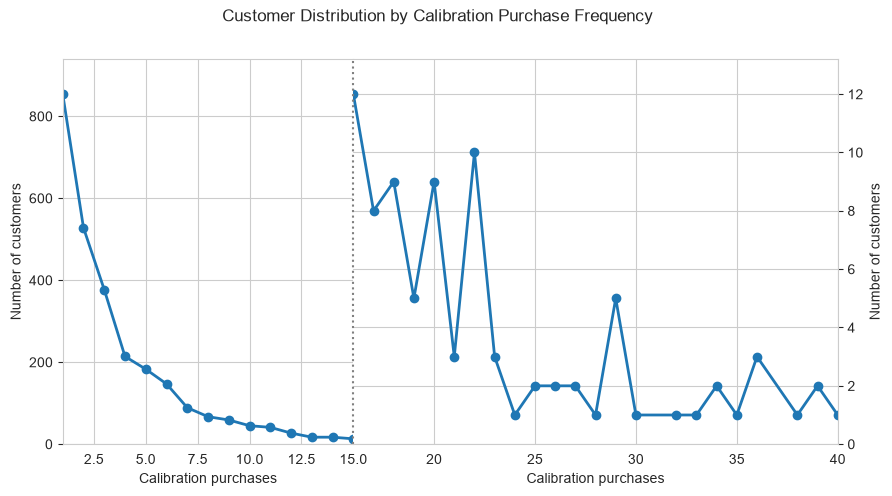

In [36]:
# predicted purchases for the holdout period
evaluation["pred_purchases"] = np.asarray(
    pareto_model.expected_purchases(data=summary_cal, future_t=holdout_period)
).ravel()

# actual purchases in holdout
actual = df_holdout.groupby("Customer_ID")["order_id"].nunique()
evaluation["actual_purchases"] = evaluation["customer_id"].map(actual).fillna(0)

plot_data = evaluation.dropna(subset=["pred_purchases", "actual_purchases"]).copy()

freq_summary = (
    plot_data[(plot_data["frequency"] >= 1) & (plot_data["frequency"] <= 40)]
    .groupby("frequency")
    .agg(
        actual_avg_purchases=("actual_purchases", "mean"),
        pred_avg_purchases=("pred_purchases", "mean"),
        n_customers=("customer_id", "size"),
    )
    .reset_index()
)

plt.figure(figsize=(10, 5))
plt.plot(
    freq_summary["frequency"],
    freq_summary["actual_avg_purchases"],
    marker="o",
    linewidth=2,
    label="Actual average purchases",
)
plt.plot(
    freq_summary["frequency"],
    freq_summary["pred_avg_purchases"],
    marker="o",
    linewidth=2,
    label="Predicted average purchases",
)
plt.xlabel("Number of purchases during calibration period")
plt.ylabel("Average number of purchases in holdout")
plt.title("Actual vs Predicted Purchases by Calibration Frequency")
plt.grid(True)
plt.legend()
plt.show()

#===================================================================
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(10, 5),
    gridspec_kw={"width_ratios": [15, 25]},
    sharex=False,
    sharey=False
)

left = freq_summary[freq_summary["frequency"] <= 15]
right = freq_summary[freq_summary["frequency"] >= 16]

ax1.plot(left["frequency"], left["n_customers"], marker="o", linewidth=2)
ax2.plot(right["frequency"], right["n_customers"], marker="o", linewidth=2)

# x limits
ax1.set_xlim(1, 15)
ax2.set_xlim(16, 40)

# independent y limits
ax1.set_ylim(0, left["n_customers"].max() * 1.1)
ax2.set_ylim(0, right["n_customers"].max() * 1.1)

# remove touching spines
ax1.spines["right"].set_visible(False)
ax2.spines["left"].set_visible(False)

# left y-axis
ax1.yaxis.set_ticks_position("left")
ax1.yaxis.set_label_position("left")
ax1.set_ylabel("Number of customers")

# right y-axis
ax2.yaxis.set_ticks_position("right")
ax2.yaxis.set_label_position("right")
ax2.set_ylabel("Number of customers")

# x labels
ax1.set_xlabel("Calibration purchases")
ax2.set_xlabel("Calibration purchases")


# dotted separator
ax1.axvline(
    x=15,
    color="gray",
    linestyle=":",
    linewidth=1.5
)


ax2.axvline(
    x=16,
    color="gray",
    linestyle=":",
    linewidth=1.5
)


fig.suptitle("Customer Distribution by Calibration Purchase Frequency")

# panels touch each other
plt.subplots_adjust(wspace=0)

plt.show()

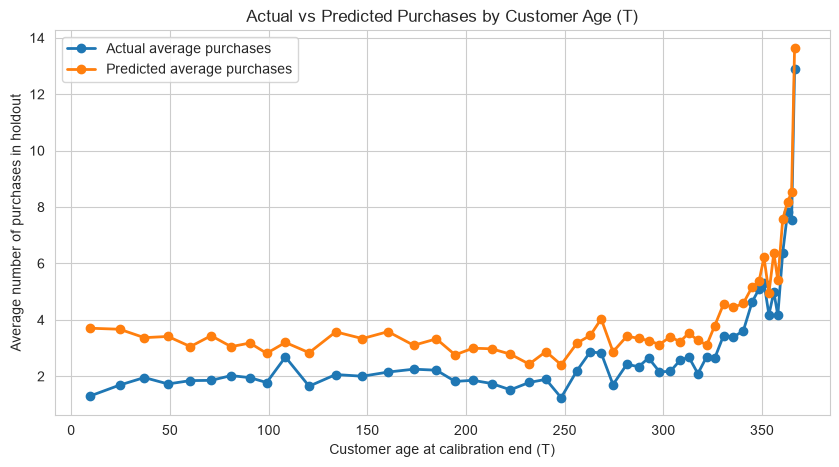

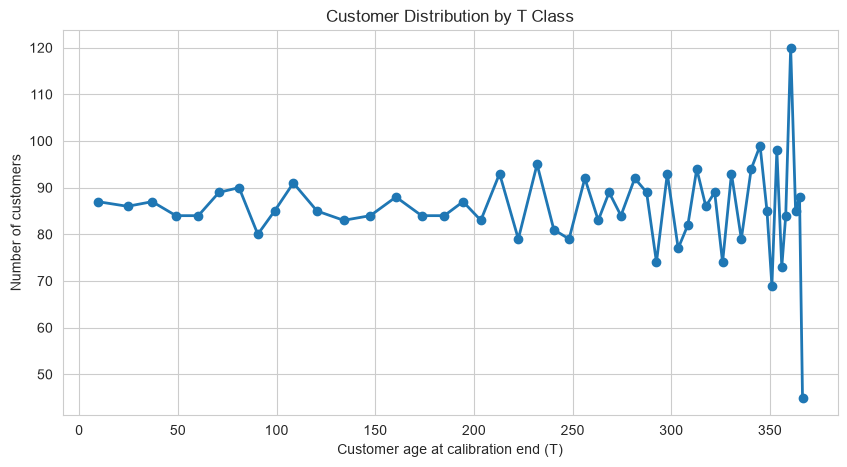

In [37]:
# --------------------------------------------------
# 1) Predict and attach actual purchases
# --------------------------------------------------
evaluation["pred_purchases"] = np.asarray(
    pareto_model.expected_purchases(data=summary_cal, future_t=holdout_period)
).ravel()

actual = df_holdout.groupby("Customer_ID")["order_id"].nunique()
evaluation["actual_purchases"] = evaluation["customer_id"].map(actual).fillna(0)

plot_data = evaluation.dropna(subset=["pred_purchases", "actual_purchases", "T"]).copy()

# --------------------------------------------------
# 2) Create about 50 classes for T using quantiles
#    T = customer age at end of calibration period
# --------------------------------------------------
plot_data["T_class"] = pd.qcut(
    plot_data["T"],
    q=50,
    duplicates="drop"
)

T_summary = (
    plot_data
    .groupby("T_class", observed=True)
    .agg(
        actual_avg_purchases=("actual_purchases", "mean"),
        pred_avg_purchases=("pred_purchases", "mean"),
        n_customers=("customer_id", "size")
    )
    .reset_index()
)

# Use class midpoints for plotting on the x-axis
T_summary["T_mid"] = T_summary["T_class"].apply(
    lambda x: (x.left + x.right) / 2
)

T_summary = T_summary.sort_values("T_mid").reset_index(drop=True)

# --------------------------------------------------
# 3) Figure 1: Actual vs Predicted purchases by T class
# --------------------------------------------------
plt.figure(figsize=(10, 5))

plt.plot(
    T_summary["T_mid"],
    T_summary["actual_avg_purchases"],
    marker="o",
    linewidth=2,
    label="Actual average purchases"
)

plt.plot(
    T_summary["T_mid"],
    T_summary["pred_avg_purchases"],
    marker="o",
    linewidth=2,
    label="Predicted average purchases"
)

plt.xlabel("Customer age at calibration end (T)")
plt.ylabel("Average number of purchases in holdout")
plt.title("Actual vs Predicted Purchases by Customer Age (T)")
plt.grid(True)
plt.legend()
plt.show()

# --------------------------------------------------
# 4) Figure 2: Customer distribution by T class
# --------------------------------------------------
plt.figure(figsize=(10, 5))

plt.plot(
    T_summary["T_mid"],
    T_summary["n_customers"],
    marker="o",
    linewidth=2
)

plt.xlabel("Customer age at calibration end (T)")
plt.ylabel("Number of customers")
plt.title("Customer Distribution by T Class")
plt.grid(True)
plt.show()

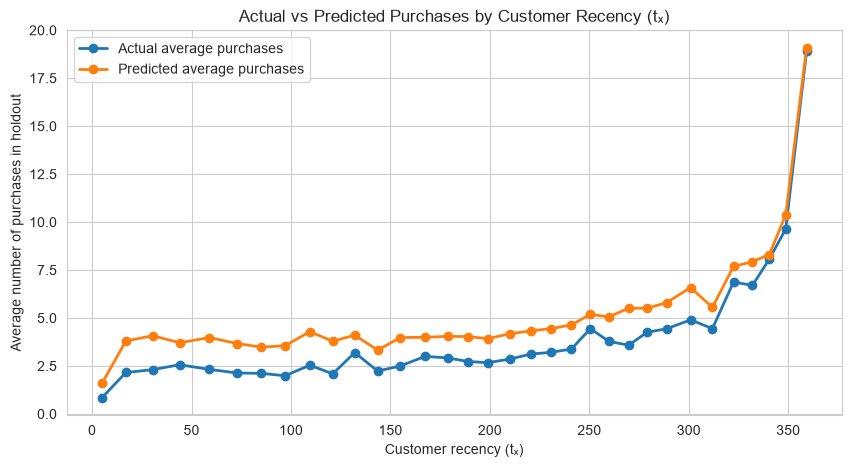

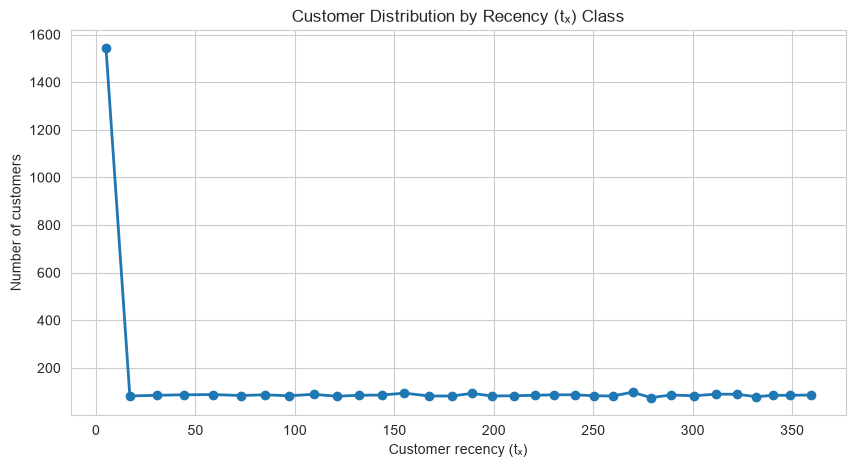

In [38]:
# --------------------------------------------------
# Create ~50 recency (t_x) classes
# --------------------------------------------------
plot_data = evaluation.dropna(
    subset=["pred_purchases", "actual_purchases", "recency"]
).copy()

plot_data["tx_class"] = pd.qcut(
    plot_data["recency"],
    q=50,
    duplicates="drop"
)

tx_summary = (
    plot_data
    .groupby("tx_class", observed=True)
    .agg(
        actual_avg_purchases=("actual_purchases", "mean"),
        pred_avg_purchases=("pred_purchases", "mean"),
        n_customers=("customer_id", "size")
    )
    .reset_index()
)

tx_summary["tx_mid"] = tx_summary["tx_class"].apply(
    lambda x: (x.left + x.right) / 2
)

tx_summary = tx_summary.sort_values("tx_mid").reset_index(drop=True)

# --------------------------------------------------
# Figure 1
# --------------------------------------------------
plt.figure(figsize=(10,5))

plt.plot(
    tx_summary["tx_mid"],
    tx_summary["actual_avg_purchases"],
    marker="o",
    linewidth=2,
    label="Actual average purchases"
)

plt.plot(
    tx_summary["tx_mid"],
    tx_summary["pred_avg_purchases"],
    marker="o",
    linewidth=2,
    label="Predicted average purchases"
)

plt.xlabel("Customer recency (tₓ)")
plt.ylabel("Average number of purchases in holdout")
plt.title("Actual vs Predicted Purchases by Customer Recency (tₓ)")
plt.grid(True)
plt.legend()

plt.show()

# --------------------------------------------------
# Figure 2
# --------------------------------------------------
plt.figure(figsize=(10,5))

plt.plot(
    tx_summary["tx_mid"],
    tx_summary["n_customers"],
    marker="o",
    linewidth=2
)

plt.xlabel("Customer recency (tₓ)")
plt.ylabel("Number of customers")
plt.title("Customer Distribution by Recency (tₓ) Class")
plt.grid(True)

plt.show()

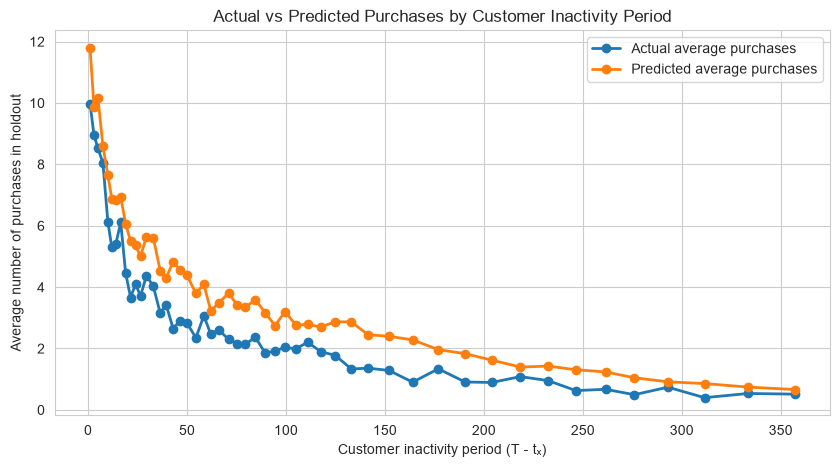

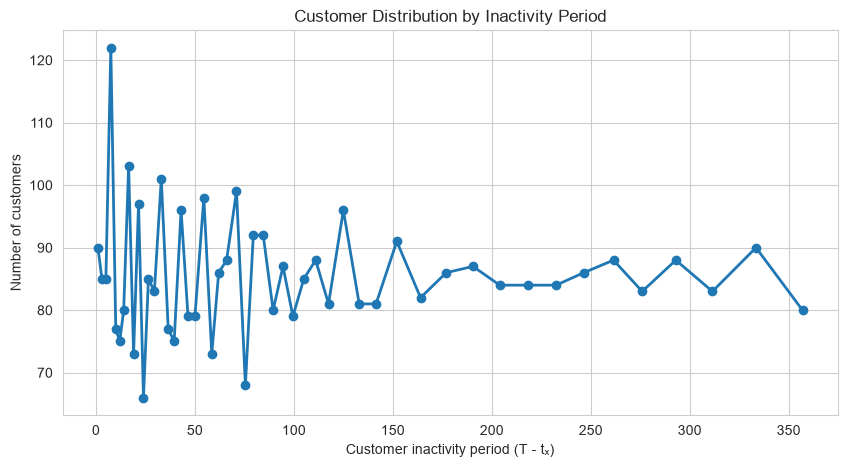

In [39]:
# customer inactivity period = T - t_x
plot_data = evaluation.dropna(
    subset=["pred_purchases", "actual_purchases", "T", "recency"]
).copy()

plot_data["inactivity"] = plot_data["T"] - plot_data["recency"]

# 50 quantile-based classes
plot_data["inactivity_class"] = pd.qcut(
    plot_data["inactivity"],
    q=50,
    duplicates="drop"
)

inact_summary = (
    plot_data
    .groupby("inactivity_class", observed=True)
    .agg(
        actual_avg_purchases=("actual_purchases", "mean"),
        pred_avg_purchases=("pred_purchases", "mean"),
        n_customers=("customer_id", "size")
    )
    .reset_index()
)

inact_summary["inact_mid"] = inact_summary["inactivity_class"].apply(
    lambda x: (x.left + x.right) / 2
)

inact_summary = inact_summary.sort_values("inact_mid").reset_index(drop=True)

# Figure 1: actual vs predicted purchases by inactivity period
plt.figure(figsize=(10, 5))

plt.plot(
    inact_summary["inact_mid"],
    inact_summary["actual_avg_purchases"],
    marker="o",
    linewidth=2,
    label="Actual average purchases"
)

plt.plot(
    inact_summary["inact_mid"],
    inact_summary["pred_avg_purchases"],
    marker="o",
    linewidth=2,
    label="Predicted average purchases"
)

plt.xlabel("Customer inactivity period (T - tₓ)")
plt.ylabel("Average number of purchases in holdout")
plt.title("Actual vs Predicted Purchases by Customer Inactivity Period")
plt.grid(True)
plt.legend()
plt.show()

# Figure 2: customer distribution by inactivity period
plt.figure(figsize=(10, 5))

plt.plot(
    inact_summary["inact_mid"],
    inact_summary["n_customers"],
    marker="o",
    linewidth=2
)

plt.xlabel("Customer inactivity period (T - tₓ)")
plt.ylabel("Number of customers")
plt.title("Customer Distribution by Inactivity Period")
plt.grid(True)
plt.show()